In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Colab/diffusion/edm

/content/drive/MyDrive/Colab/diffusion/edm


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid

transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
trainset = torchvision.datasets.CIFAR10(root='./sigma_model/data', train=True, download=True, transform=transform)

transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
testset = torchvision.datasets.CIFAR10(root='./sigma_model/data', train=False, download=True, transform=transform)

train_images = torch.stack([trainset[i][0] for i in range(len(trainset))])
test_images = torch.stack([testset[i][0] for i in range(len(testset))])

train_images.shape, test_images.shape


(torch.Size([50000, 3, 32, 32]), torch.Size([10000, 3, 32, 32]))

In [ ]:
def grad_x_log_pdf(x, sigma, x_all):
    norm2 = ((x - x_all) ** 2).sum(dim=(1, 2, 3))
    sigma_norm2 = -1 / (2 * sigma ** 2) * norm2
    delta = torch.max(sigma_norm2) #torch.tensor(0.0)
    exp_norm2 = ( sigma_norm2 - delta ).exp()
    numerator = exp_norm2[:, None, None, None] * ( -(x - x_all) / sigma**2 )
    denominator = exp_norm2
    result = numerator.sum(dim=(0)) / denominator.sum()
    return result

In [ ]:
def denoise_from_grad(x, sigma, x_all):
    return grad_x_log_pdf(x, sigma, x_all) * sigma**2 + x

In [ ]:
def ideal_denoiser(x, sigma, x_all):
    norm2 = ((x - x_all[:,None, :, :, :]) ** 2).sum(dim=(2, 3, 4))
    sigma_norm2 = -1 / (2 * sigma ** 2) * norm2
    delta = torch.max(sigma_norm2, dim=0)[0] #torch.tensor(0.0)
    exp_norm2 = ( sigma_norm2 - delta ).exp()
    numerator = exp_norm2[:, :, None, None, None] * ( x_all[:,None, :, :, :] )
    denominator = exp_norm2
    result = numerator.sum(dim=(0)) / denominator.sum()
    return result

In [ ]:
def min_max_norm_batch_0_1(x: torch.tensor):
    """Returns the min-max normalization of x across each image in batch."""
    batch_size = x.shape[0]
    x_reshaped = x.view(batch_size, -1)  # Reshape each image to (batch_size, num_elements)
    min_vals = x_reshaped.min(dim=1, keepdim=True)[0].view(batch_size, 1, 1, 1)
    max_vals = x_reshaped.max(dim=1, keepdim=True)[0].view(batch_size, 1, 1, 1)
    return (x - min_vals) / (max_vals - min_vals + 1e-8)  # Adding epsilon to avoid division by zero


In [ ]:
def show_batch_imgs(imgs,nrow=4):
    img_grid = make_grid(imgs,nrow=nrow,padding=2)
    img_tmp = torchvision.transforms.ToPILImage()(img_grid)
    display(img_tmp) # img_tmp.show()
    #fig=plt.figure()
    #fig.set_size_inches(1,8)
    #plt.imshow(img_grid.permute(1,2,0))
    #plt.axis('off')
    #plt.show()
    return

In [ ]:
from tqdm import tqdm
import pickle
import numpy as np
import torch
import PIL.Image
import dnnlib
import matplotlib.pyplot as plt
import os
from sigma_model.resnet_regression import ResNet18Regression_x

In [ ]:
def load_denoise_model(network_pkl, device=torch.device('cuda')):
    print(f'Loading networks from "{network_pkl}"...')
    with dnnlib.util.open_url(network_pkl) as f:
        net = pickle.load(f)['ema'].to(torch.device(device))
    return net

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device:{device}\n')

# loading denoise model
# denoise_model_path = 'https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-cond-vp.pkl'
denoise_model_path = 'https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-ve.pkl'
denoise_model = load_denoise_model(denoise_model_path, device)


Using device:cpu

Loading networks from "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-ve.pkl"...


In [ ]:
def load_sigma_model(checkpoint_path, device=torch.device('cuda')):
    print(f'Loading sigma model from "{checkpoint_path}"...')
    # Model
    net = ResNet18Regression_x().to(device)
    # Load checkpoint.
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    net.load_state_dict(checkpoint['model_state_dict'])

    net.to(device) #?
    net.eval()
    return net

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device:{device}\n')

# loading sigma model
# sigma_model_path = './sigma_model/checkpoint/ckpt_60_maincifar_with_sigma4_L2.pth'
sigma_model_path = './sigma_model/checkpoints_sigma_estimation/checkpoint.pth'
sigma_model = load_sigma_model(sigma_model_path, device)

In [ ]:
train_images[96].shape

torch.Size([3, 32, 32])

steps= tensor([1.0000e+00, 2.0810e-01, 4.2112e-02, 7.3181e-03, 2.5000e-05],
       dtype=torch.float64)


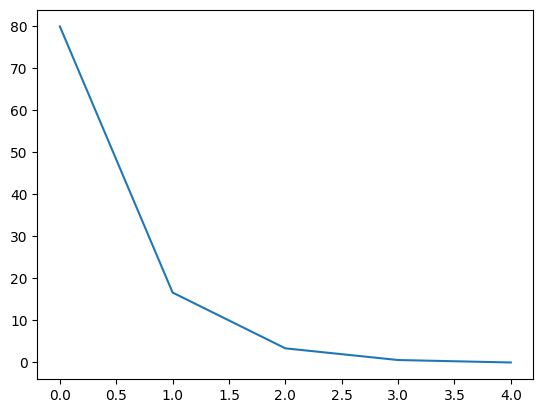

In [ ]:
def calculate_t_steps(num_steps, alpha, sigma_min, sigma_max, device):
    b = torch.tensor(num_steps * alpha, dtype=torch.float64)
    step_indices = torch.arange(num_steps + 1, dtype=torch.float64, device=device)
    t_steps = (sigma_max - sigma_min) * (torch.exp((num_steps - step_indices) / b) - 1) / (torch.exp(num_steps / b) - 1) + sigma_min
    return t_steps

steps = calculate_t_steps(num_steps=4, alpha=0.16, sigma_min=0.002, sigma_max=80.0, device='cpu')
print('steps=',steps/80)
plt.plot(steps)
plt.show()

input image:


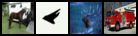

noisy input:


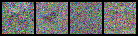

net_denoised_img:


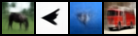

In [ ]:
inputs = test_images[20:24]#[None, :, :, :] #train_images

sigma_ = torch.tensor([2.0], dtype=torch.float64)
eps = torch.randn_like(inputs).to(device)
sigma = sigma_[:, None, None, None]
noisy_inputs = inputs + sigma * eps

x_cur = noisy_inputs.to(torch.float64)
net_denoised_img = denoise_model(x_cur, sigma_, class_labels = None).to(torch.float64)

print('input image:')
show_batch_imgs(min_max_norm_batch_0_1(inputs))
print('noisy input:')
show_batch_imgs(min_max_norm_batch_0_1(noisy_inputs))
print('net_denoised_img:')
show_batch_imgs(min_max_norm_batch_0_1(net_denoised_img))


input image:


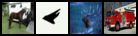

noisy input:


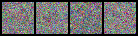

net_denoised_img:


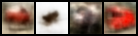

In [ ]:
inputs = test_images[20:24]#[None, :, :, :] #train_images

sigma_ = torch.tensor([5.0], dtype=torch.float64)
eps = torch.randn_like(inputs).to(device)
sigma = sigma_[:, None, None, None]
noisy_inputs = inputs + sigma * eps

x_cur = noisy_inputs.to(torch.float64)
net_denoised_img = denoise_model(x_cur, sigma_, class_labels = None).to(torch.float64)
grad_x_log_pdf_value = - (x_cur - net_denoised_img) / sigma_**2




print('input image:')
show_batch_imgs(min_max_norm_batch_0_1(inputs))
print('noisy input:')
show_batch_imgs(min_max_norm_batch_0_1(noisy_inputs))
print('net_denoised_img:')
show_batch_imgs(min_max_norm_batch_0_1(net_denoised_img))


magnitude1 tensor([5216.2628, 4924.4752, 5238.5907, 5183.6089], dtype=torch.float64)
magnitude2 tensor([57.9205, 54.6318, 58.0387, 57.5013], dtype=torch.float64)
magnitude3 tensor([0.1885, 0.2089, 0.2357, 0.2004], dtype=torch.float64)
magnitude4 tensor([0.0008, 0.0008, 0.0010, 0.0010], dtype=torch.float64)
input image:


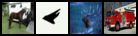

noisy input: tensor([80.2592, 77.9395, 80.3665, 80.0063], dtype=torch.float64)


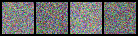

noise1: tensor([72.2346, 70.1433, 72.3285, 72.0070], dtype=torch.float64)


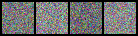

net_denoised_img:


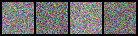

noise2: tensor([7.6117, 7.3924, 7.6193, 7.5842], dtype=torch.float64)


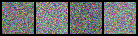

net_denoised_img2:


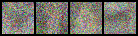

noise3: tensor([0.4342, 0.4219, 0.4414, 0.4465], dtype=torch.float64)


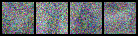

net_denoised_img3:


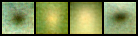

noise4: tensor([0.0277, 0.0212, 0.0232, 0.0313], dtype=torch.float64)


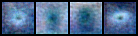

net_denoised_img4:


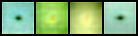

In [ ]:
inputs = test_images[20:24]#[None, :, :, :] #train_images

sigma_ = torch.tensor([80.0], dtype=torch.float64)
eps = torch.randn_like(inputs).to(device)
sigma = sigma_[:, None, None, None]
noisy_inputs =   sigma * eps #inputs +
std0 = noisy_inputs.std(dim=(1, 2, 3))
x_cur = noisy_inputs.to(torch.float64)

alpha_t = 0.1
net_denoised_img = denoise_model(x_cur, torch.tensor([80.0], dtype=torch.float64), class_labels = None).to(torch.float64)
net_denoised_img = net_denoised_img * (1 - alpha_t) + x_cur * alpha_t
noise1 = net_denoised_img - x_cur
std1 = noise1.std(dim=(1, 2, 3))
magnitude1 = (noise1**2).mean(dim=(1, 2, 3))
print('magnitude1',magnitude1)

net_denoised_img2 = denoise_model(net_denoised_img , torch.tensor([80.0 * alpha_t], dtype=torch.float64), class_labels = None).to(torch.float64)
alpha_t = 0.05
net_denoised_img2 = net_denoised_img2 * (1 - alpha_t) + net_denoised_img * alpha_t
noise2 = net_denoised_img2 - net_denoised_img
std2 = noise2.std(dim=(1, 2, 3))
magnitude2 = (noise2**2).mean(dim=(1, 2, 3))
print('magnitude2',magnitude2)

net_denoised_img3 = denoise_model(net_denoised_img2 , torch.tensor([80.0 * alpha_t], dtype=torch.float64), class_labels = None).to(torch.float64)
alpha_t = 0.01
net_denoised_img3 = net_denoised_img3 * (1 - alpha_t) + net_denoised_img2 * alpha_t
noise3 = net_denoised_img3 - net_denoised_img2
std3 = noise3.std(dim=(1, 2, 3))
magnitude3 = (noise3**2).mean(dim=(1, 2, 3))
print('magnitude3',magnitude3)

net_denoised_img4 = denoise_model(net_denoised_img3 , torch.tensor([80.0 * alpha_t], dtype=torch.float64), class_labels = None).to(torch.float64)
alpha_t = 0.005
net_denoised_img4 = net_denoised_img4 * (1 - alpha_t) + net_denoised_img3 * alpha_t
noise4 = net_denoised_img4 - net_denoised_img3
std4 = noise4.std(dim=(1, 2, 3))
magnitude4 = (noise4**2).mean(dim=(1, 2, 3))
print('magnitude4',magnitude4)

print('input image:')
show_batch_imgs(min_max_norm_batch_0_1(inputs))

print('noisy input:', std0)
show_batch_imgs(min_max_norm_batch_0_1(noisy_inputs))

print('noise1:',std1)
show_batch_imgs(min_max_norm_batch_0_1(noise1))
print('net_denoised_img:')
show_batch_imgs(min_max_norm_batch_0_1(net_denoised_img))

print('noise2:',std2)
show_batch_imgs(min_max_norm_batch_0_1(noise2))
print('net_denoised_img2:')
show_batch_imgs(min_max_norm_batch_0_1(net_denoised_img2))

print('noise3:',std3)
show_batch_imgs(min_max_norm_batch_0_1(noise3))
print('net_denoised_img3:')
show_batch_imgs(min_max_norm_batch_0_1(net_denoised_img3))

print('noise4:',std4)
show_batch_imgs(min_max_norm_batch_0_1(noise4))
print('net_denoised_img4:')
show_batch_imgs(min_max_norm_batch_0_1(net_denoised_img4))


In [ ]:
inputs = test_images[20:24]#[None, :, :, :] #train_images

sigma_ = torch.tensor([2.0], dtype=torch.float64)
eps = torch.randn_like(inputs).to(device)
sigma = sigma_[:, None, None, None]
noisy_inputs = inputs + sigma * eps

x_cur = noisy_inputs.to(torch.float64)
net_denoised_img = denoise_model(x_cur, sigma_, class_labels = None).to(torch.float64)
ideal_denoised_img = ideal_denoiser(noisy_inputs.squeeze(), sigma_, train_images)
print('input image:')
show_batch_imgs(min_max_norm_batch_0_1(inputs))
print('noisy input:')
show_batch_imgs(min_max_norm_batch_0_1(noisy_inputs))
print('net_denoised_img:')
show_batch_imgs(min_max_norm_batch_0_1(net_denoised_img))
print('ideal_denoised_img:')
show_batch_imgs(min_max_norm_batch_0_1(ideal_denoised_img)) #

NameError: name 'ideal_denoiser' is not defined

In [ ]:
sigma_model

In [ ]:
inputs = test_images[20:24]#[None, :, :, :] #train_images

sigma_ = torch.tensor([3.0], dtype=torch.float64)
eps = torch.randn_like(inputs).to(device)
sigma = sigma_[:, None, None, None]
noisy_inputs = inputs + sigma * eps

x_cur = noisy_inputs.to(torch.float64)
sigma_1 = torch.tensor([2.0], dtype=torch.float64)
net_denoised_img = denoise_model(x_cur, sigma_1, class_labels = None).to(torch.float64)
noise_estimate = net_denoised_img - x_cur
sigma_estimate_before = sigma_model(x_cur.to(torch.float32))
sigma_estimate_after = sigma_model(net_denoised_img.to(torch.float32))
delta_x = 0.15 * (net_denoised_img - x_cur)
x_next = x_cur + delta_x
sigma_x_next = sigma_model(x_next.to(torch.float32))

print('sigma_estimate before =\n',sigma_estimate_before)
print('sigma_estimate after =\n',sigma_estimate_after)
print('noise_estimate.std =\n',noise_estimate.std(dim=(1,2,3)))
print('sigma_x_next =\n',sigma_x_next)


print('input image:')
show_batch_imgs(min_max_norm_batch_0_1(inputs))
print('noisy input:')
show_batch_imgs(min_max_norm_batch_0_1(noisy_inputs))
print('net_denoised_img:')
show_batch_imgs(min_max_norm_batch_0_1(net_denoised_img))
print('noise_estimate:')
show_batch_imgs(min_max_norm_batch_0_1(noise_estimate)) #
print('x_next:')
show_batch_imgs(min_max_norm_batch_0_1(x_next)) #

NameError: name 'sigma_model' is not defined

In [ ]:

noisy_inputs = x_next

x_cur = noisy_inputs.to(torch.float64)
sigma_1 = sigma_x_next #torch.tensor([1.8], dtype=torch.float64)
net_denoised_img = denoise_model(x_cur, sigma_1, class_labels = None).to(torch.float64)
noise_estimate = net_denoised_img - x_cur
sigma_estimate_before = sigma_model(x_cur.to(torch.float32))
sigma_estimate_after = sigma_model(net_denoised_img.to(torch.float32))
delta_x = 0.15 * (net_denoised_img - x_cur)
x_next = x_cur + delta_x
sigma_x_next = sigma_model(x_next.to(torch.float32))

print('sigma_estimate before =\n',sigma_estimate_before)
print('sigma_estimate after =\n',sigma_estimate_after)
print('noise_estimate.std =\n',noise_estimate.std(dim=(1,2,3)))
print('sigma_x_next =\n',sigma_x_next)


print('input image:')
show_batch_imgs(min_max_norm_batch_0_1(inputs))
print('noisy input:')
show_batch_imgs(min_max_norm_batch_0_1(noisy_inputs))
print('net_denoised_img:')
show_batch_imgs(min_max_norm_batch_0_1(net_denoised_img))
print('noise_estimate:')
show_batch_imgs(min_max_norm_batch_0_1(noise_estimate)) #
print('x_next:')
show_batch_imgs(min_max_norm_batch_0_1(x_next)) #

NameError: name 'x_next' is not defined